In [1]:
# Step 1 — Import required libraries
import pandas as pd
import numpy as np
from pathlib import Path

print("Libraries imported successfully ✅")

Libraries imported successfully ✅


In [2]:
# Step 2 — Define data path and load interactions dataset
DATA_PATH = Path("../../data/raw")

# Load interactions dataset
df = pd.read_csv(DATA_PATH / "interactions.csv")

# Convert timestamp column to datetime format
df['timestamp'] = pd.to_datetime(df['timestamp'])

print("Data loaded successfully ✅")
df.head()

Data loaded successfully ✅


,user_id,reel_id,view,watch_ratio,like,comment,purchase,timestamp
0,1,1191,1,0.84,0,0,0,2025-12-12 15:49:21.170953
1,1,2506,1,0.71,0,1,0,2025-12-28 15:49:21.544868
2,1,1764,1,0.67,0,0,0,2026-02-18 15:49:21.340695
3,1,2777,1,0.91,1,0,0,2026-02-17 15:49:21.619322
4,1,1074,1,0.70,0,0,0,2026-02-09 15:49:21.135591


In [3]:
# Step 3 — Compute base interaction score for each row
# We assign weights to different interaction types: view, watch_ratio, like, comment, purchase

df['base_score'] = (
    1 * df['view'] +
    2 * df['watch_ratio'] +
    3 * df['like'] +
    2 * df['comment'] +
    5 * df['purchase']
)

print("Base interaction score calculated ✅")
df[['reel_id', 'base_score']].head()

Base interaction score calculated ✅


,reel_id,base_score
0,1191,2.68
1,2506,4.42
2,1764,2.34
3,2777,5.82
4,1074,2.40


In [4]:
# Step 4 — Apply exponential time decay weighting
# Formula: decay_weight = exp(-lambda_decay * Δt)

lambda_decay = 0.001  # decay factor (tune if needed)
max_timestamp = df['timestamp'].max()
df['time_diff_days'] = (max_timestamp - df['timestamp']).dt.total_seconds() / (60*60*24)

# Apply exponential decay
df['decay_weight'] = np.exp(-lambda_decay * df['time_diff_days'])

print("Time decay weights calculated ✅")
df[['timestamp', 'time_diff_days', 'decay_weight']].head()

Time decay weights calculated ✅


,timestamp,time_diff_days,decay_weight
0,2025-12-12 15:49:21.170953,89.000005,0.914846
1,2025-12-28 15:49:21.544868,73.000001,0.929601
2,2026-02-18 15:49:21.340695,21.000003,0.979219
3,2026-02-17 15:49:21.619322,22.000000,0.978240
4,2026-02-09 15:49:21.135591,30.000006,0.970446


In [5]:
# Step 5 — Compute final time-weighted score
df['time_weighted_score'] = df['base_score'] * df['decay_weight']

print("Final time-weighted score calculated ✅")
df[['reel_id', 'time_weighted_score']].head()

Final time-weighted score calculated ✅


,reel_id,time_weighted_score
0,1191,2.451786
1,2506,4.108836
2,1764,2.291372
3,2777,5.693358
4,1074,2.329069


In [6]:
# Step 6 — Aggregate scores per reel
time_decay_popularity = (
    df.groupby('reel_id')['time_weighted_score']
      .sum()
      .reset_index()
      .sort_values('time_weighted_score', ascending=False)
)

print("Time-decay popularity ranking ready ✅")
time_decay_popularity.head(10)

Time-decay popularity ranking ready ✅


,reel_id,time_weighted_score
2548,2549,150.793985
1059,1060,148.661736
2620,2621,141.112268
673,674,139.933661
1463,1464,136.855303
2850,2851,135.532976
1728,1729,135.527789
464,465,133.578000
1847,1848,133.371600
2277,2278,133.111321


In [7]:
# Step 7 — Define recommendation function
def recommend_time_decay(top_k=10):
    """
    Returns top_k reels ranked by time-decayed popularity score
    """
    return time_decay_popularity.head(top_k)['reel_id'].tolist()

# Example usage
recommend_time_decay(10)

[2549, 1060, 2621, 674, 1464, 2851, 1729, 465, 1848, 2278]

In [8]:
# Step 8 — Save time-decay scores to processed folder
processed_path = Path("../../data/processed")
processed_path.mkdir(parents=True, exist_ok=True)

time_decay_popularity.to_csv(
    processed_path / "time_decay_scores.csv",
    index=False
)

print("Time decay scores saved successfully ✅")

Time decay scores saved successfully ✅


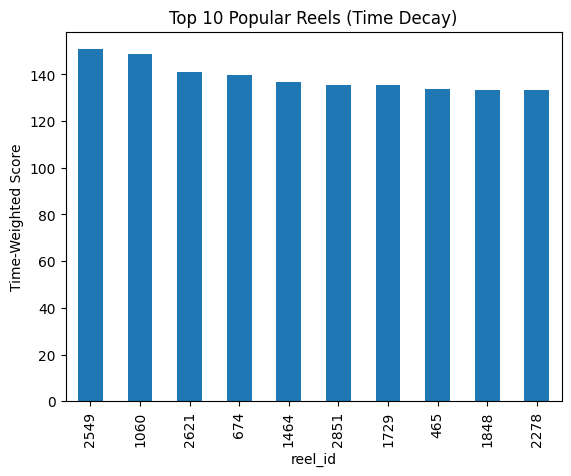

In [9]:
# Step 9 — Simple bar plot for top 10 reels
import matplotlib.pyplot as plt

time_decay_popularity.head(10).plot.bar(
    x='reel_id', y='time_weighted_score', legend=False
)
plt.title("Top 10 Popular Reels (Time Decay)")
plt.ylabel("Time-Weighted Score")
plt.show()

In [10]:
# Step 10 — Compare Top 10 Popularity vs Time Decay Reels

# Get top 10 from baseline popularity
top10_baseline = popularity.head(10)['reel_id'].tolist()

# Get top 10 from time decay
top10_time_decay = time_decay_popularity.head(10)['reel_id'].tolist()

print("Top 10 Baseline Popularity:", top10_baseline)
print("Top 10 Time Decay Popularity:", top10_time_decay)

NameError: name 'popularity' is not defined

In [13]:
# Step 10 — Compare Top 10 Popularity vs Time Decay Reels
import pandas as pd
from pathlib import Path

processed_path = Path("../../data/processed")

# Load baseline popularity scores
popularity = pd.read_csv(processed_path / "popularity_scores.csv")

# Load time-decay scores
time_decay_popularity = pd.read_csv(processed_path / "time_decay_scores.csv")

# Now you can do the Top-10 comparison
top10_baseline = popularity.head(10)['reel_id'].tolist()
top10_time_decay = time_decay_popularity.head(10)['reel_id'].tolist()

print("Top 10 Baseline Popularity:", top10_baseline)
print("Top 10 Time Decay Popularity:", top10_time_decay)

Top 10 Baseline Popularity: [1060, 2549, 2621, 674, 1729, 1464, 465, 2278, 125, 2851]
Top 10 Time Decay Popularity: [2549, 1060, 2621, 674, 1464, 2851, 1729, 465, 1848, 2278]


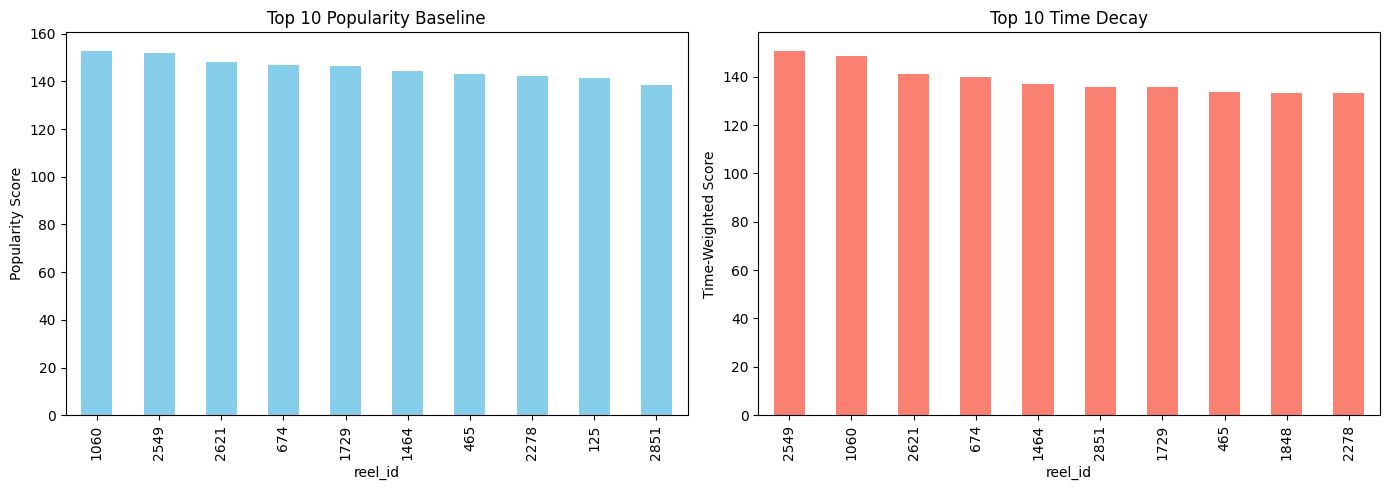

In [14]:
# Step 11 — Visualize the top 10 comparison
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Baseline plot
popularity.head(10).plot.bar(
    x='reel_id', y='popularity_score', legend=False, ax=axes[0], color='skyblue'
)
axes[0].set_title("Top 10 Popularity Baseline")
axes[0].set_ylabel("Popularity Score")

# Time Decay plot
time_decay_popularity.head(10).plot.bar(
    x='reel_id', y='time_weighted_score', legend=False, ax=axes[1], color='salmon'
)
axes[1].set_title("Top 10 Time Decay")
axes[1].set_ylabel("Time-Weighted Score")

plt.tight_layout()
plt.show()

In [15]:
# Step 12 — Analysis Notes

"""
1. Compare the differences in top reels between baseline and time-decay.
2. Check if recently active reels appear higher in Time Decay ranking.
3. Use these insights for Hybrid Model weighting.
4. Optional: Track overlap percentage between top 10 lists.
"""

# Example: overlap
overlap = set(top10_baseline).intersection(set(top10_time_decay))
print(f"Overlap between Baseline and Time Decay Top-10: {len(overlap)} reels")

Overlap between Baseline and Time Decay Top-10: 9 reels
